### **Human Ovary Atlas - snucRNA-seq preprocessing** ###
**Written by:** Josef Byrne

**Purpose:** Preprocess CellBender-corrected 10x Flex snucRNA-seq matrices into a merged AnnData object for downstream analysis. Doublets were detected on a per-sample basis and retained as annotations at this stage. Per-sample low-quality nuclei were removed using median absolute deviation-based filters for total counts and detected genes, followed by removal of nuclei with >10% mitochondrial reads.

In [ ]:
# Imports & Settings
import os
import sys
sys.path.append('/path/to/utils/directory')
from utils_OvaryAtlas import get_session_info

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import median_abs_deviation
import math

import anndata as ad
import scanpy as sc
import pyucell as uc

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
pd.set_option('display.max_column', None)
pd.options.display.max_rows = 100

from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42
sc.settings.set_figure_params(dpi=150, color_map='RdPu', dpi_save=150, vector_friendly=True, format='pdf')

import rpy2.robjects as ro
import rpy2.robjects.numpy2ri
rpy2.robjects.numpy2ri.activate()
%load_ext rpy2.ipython

In [ ]:
### Define directories ###
nostromo_datadir="/path/to/project_directory"
python_analyses_dir = f"{nostromo_datadir}/python_analyses"
adata_objdir = f"{python_analyses_dir}/adata_objs"

cellbender_adata_dir = f"{adata_objdir}/cellbender_intermeds"
patient_metadata_path = f"{nostromo_datadir}/dispersed_donor_covariates_cleaned.tsv"

#### Define preprocessing functions ####

In [3]:
### Set up functions to use for data pre-processing ###

# FUNCTION (helper): Identifies outliers for metrics based on being beyond a given median absolute deviation (MAD)
# Supporting function for remove_outliers
def is_outlier(adata, metric, nmads=5):
    M = adata.obs[metric]
    outliers = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outliers

# FUNCTION: Removes outliers from each adata object based on deviation from 5MAD, returns a list
# containing adata object with outliers removed ("adata_cleaned" element) and
# a data frame containing the # of outliers removed for each outlier
# type for tracking in outlier metrics ("outlier_metrics" element)
def remove_outliers(adata, nmads=5):
    # Calculate outliers
    total_counts_outliers = is_outlier(adata, 'log1p_total_counts', nmads)
    gene_counts_outliers = is_outlier(adata, 'log1p_n_genes_by_counts', nmads)
    all_outliers = total_counts_outliers | gene_counts_outliers

    # Report the number of outliers
    sum_tot_count_outliers = np.sum(total_counts_outliers)
    sum_gene_count_outliers = np.sum(gene_counts_outliers)
    sum_all_count_outliers = np.sum(all_outliers)

    print(f"{sum_tot_count_outliers} cells outside {nmads}MAD for total RNA counts\n"
          f"{sum_gene_count_outliers} cells outside {nmads}MAD for total gene counts\n"
          f"{sum_all_count_outliers} cells outliers excluded in total")

    outlier_metrics = {
        'total_count_outliers': sum_tot_count_outliers,
        'gene_count_outliers': sum_gene_count_outliers,
        'all_count_outliers': sum_all_count_outliers
    }

    # Remove outliers
    adata_cleaned = adata[~all_outliers]

    return adata_cleaned, outlier_metrics

# FUNCTION (using R): Marks doublets using scDblFinder in R, Input = raw counts dataframe for 1 sample,
# Output = doublet classification to be assigned to adata
def mark_doublets_scdblfinder(adata):

    print(f"Finding doublets for: {adata.obs['sample_ID'].iloc[0]}")

    # Convert the data matrix to a format that can be passed to R
    data_mat = adata.layers['raw_counts'].T.toarray()  # Transpose to match R's expectation of genes x cells

    # Assign the matrix to an R variable using rpy2
    ro.r.assign("data_mat", data_mat)

    # Run the R code using %%R magic or execute it using rpy2
    r_code = """
    library(Seurat)
    library(scater)
    library(scDblFinder)
    library(BiocParallel)

    set.seed(42)
    sce = scDblFinder(
        SingleCellExperiment(
            list(counts=data_mat)
        )
    )
    doublet_score = sce$scDblFinder.score
    doublet_class = as.character(sce$scDblFinder.class)
    """

    # Execute the R code
    ro.r(r_code)

    # Retrieve the R objects back to Python
    doublet_score = np.array(ro.r('doublet_score'))
    doublet_class = np.array(ro.r('doublet_class'))

    # Add the results to the obs dataframe of the current AnnData object
    adata.obs["scDblFinder_score"] = doublet_score
    adata.obs["scDblFinder_class"] = doublet_class

    return(adata)

# FUNCTION: Add patient metadata to AnnData object based on input CSV file
def add_patient_metadata(adata, metadata):
    row_metadata = metadata[(metadata['SenNet_ID'] == adata.obs['SenNet_ID'].unique()[0])]
    if row_metadata.shape[0] != 1:
        print(f"Warning: The Sample ID in the AnnData object does not match exactly one row in the metadata CSV for {adata.obs['sample_ID'].unique()[0]}")
        # raise ValueError("The Sample ID in the AnnData object does not match exactly one row in the metadata CSV.")
    for col in row_metadata.columns:
        if col != "SenNet_ID":
            adata.obs[col] = row_metadata[col].values[0]
    return adata

#### Import CellBender-corrected matrices ####

In [4]:
# Import cellbender corrected adata objects
adata_list = []

for file_name in os.listdir(cellbender_adata_dir):
    if file_name.endswith(".h5ad"):
        file_path = os.path.join(cellbender_adata_dir, file_name)

        # Load matrix data using Scanpy
        adata_cb = sc.read_h5ad(file_path)

        # Add the AnnData object to the list
        adata_list.append(adata_cb)

In [6]:
len(adata_list)

64

#### Per-sample QC and doublet detection

In [ ]:
### Execute per-sample preprocessing and QC assessment ###

# Mark mito genes and run scanpy QC
for i, adata in enumerate(adata_list):
    # Mark mito genes
    adata.var['mito'] = adata.var_names.str.startswith('MT-')

    # Run scanpy QC
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mito'], inplace=True, log1p=True)


# Initialize the metrics list
metrics_list = []

# Assume data_vec is a list of AnnData objects, one per sample
for i, adata in enumerate(adata_list):
    print(f"Processing sample: {adata.obs['sample_ID'].iloc[0]}")
    initial_cells = adata.n_obs

    # Mark doublets
    adata = mark_doublets_scdblfinder(adata)
    doublet_count = np.sum(adata.obs['scDblFinder_class'] == 'doublet')
    doublet_percent = (doublet_count / initial_cells) * 100

    # Identify and remove outliers
    adata_cleaned, outlier_metrics = remove_outliers(adata)

    # Update adata with outlier removed cleaned data
    adata_list[i] = adata_cleaned

    # Store remaining cells variable
    remaining_cells = adata_cleaned.n_obs


    sample_id = str(adata.obs["sample_ID"].iloc[0])
    plex = str(adata.obs["plex"].iloc[0])
    unique_sample_id = f"{sample_id}_{plex}"

    # Append the metrics to list of dicts
    metrics_list.append({
        "unique_sample_ID": unique_sample_id,
        "sample_ID": sample_id,
        "plex": plex,
        "initial_nuclei": initial_cells,
        "scDblFinder_doublet_count": doublet_count,
        "scDblFinder_doublet_percent": doublet_percent,
        "total_count_outliers_5MAD": outlier_metrics["total_count_outliers"],
        "gene_count_outliers_5MAD": outlier_metrics["gene_count_outliers"],
        "all_count_gene_outliers_5MAD": outlier_metrics["all_count_outliers"],
        "nuclei_after_count_gene_outlier_removal": remaining_cells,
        "median_percent_mito": np.nanmedian(adata.obs["pct_counts_mito"])
    })

# Convert the list of dicts to df
cell_qc_metrics = pd.DataFrame(metrics_list)

# Write out the results
cell_qc_metrics.to_csv(f"{python_analyses_dir}/CellQC_metrics_python.csv", index=False)

# Load patient metadata
patient_metadata = pd.read_csv(patient_metadata_path, sep='\t')

# Add patient metadata
adata_list = [add_patient_metadata(adata, patient_metadata) for adata in adata_list]

#### Merge samples

In [96]:
### Concatenate adata objects ###
merged_adata = ad.concat(adata_list, join='outer', merge='same', index_unique='-')

In [ ]:
# Create a new obs column combining sample_ID and plex to generate unique sample_ID for each ovary tissue piece analyzed (64 total)
merged_adata.obs['unique_sample_ID'] = merged_adata.obs['sample_ID'].astype(str) + "_" + merged_adata.obs['plex'].astype(str)

In [98]:
merged_adata

AnnData object with n_obs × n_vars = 460100 × 18099
    obs: 'background_fraction', 'cell_probability', 'sample_ID', 'SenNet_ID', 'plex', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'scDblFinder_score', 'scDblFinder_class', 'Age', 'BMI', 'NonOvarian_Cancer_State', 'Smoking_Status_Former', 'Para', 'Para_Gravida_Ratio', 'Simplified_Race_Ethnicity', 'Ovarian_Specific_Benign_Finding', 'Pelvic_Organ_Prolapse', 'Premalignant_Cervical', 'Urinary_Incontinence', 'Procedure_Day', 'Days_Since_Earliest', 'Is_Cancer_Staging_Procedure', 'Uterine_Pathology', 'Surgical_Approach', 'unique_sample_ID'
    var: 'gene_ids', 'feature_types', 'genome', 'mito'
    layers: 'raw_counts'

#### Immediate-early response scoring (for later per-sample StressScore construction)

In [ ]:
# Calculate IER scores per cell
# IER Gene Set (Marsh 2022, Nat Neuroscience - Supp Tab 21 "All Shared" sheet, >= 3 dataset overlap), Hspa1a mouse --> HSPA1A + HSPA1B human
stress_signature_marsh = {"marsh_stress": ["ATF3", "DUSP1", "EGR1", "FOS", "GEM", "HSP90AA1", "HSPA1A", "HSPA1B", "IER5", "JUN", "JUNB", "JUND", "KLF2", "NFKBIZ", "RHOB", "ZFP36"]}

# Determine which genes in each IER signature are present in the merged AnnData object
all_genes = merged_adata.var_names if hasattr(merged_adata, "var_names") else merged_adata.var.index

for sig_name, sig_genes in stress_signature_marsh.items():
    genes_in = [gene for gene in sig_genes if gene in all_genes]
    missing = [gene for gene in sig_genes if gene not in all_genes]
    print(f"[{sig_name}] Signature genes found: {len(genes_in)}/{len(sig_genes)}  Missing: {', '.join(missing) if missing else 'None'}")

[marsh_stress] Signature genes found: 16/16  Missing: None


In [100]:
# Calculate IER score per cell using UCell
uc.compute_ucell_scores(merged_adata, signatures=stress_signature_marsh, max_rank=2000, ties_method='max', n_jobs=-1, chunk_size=1000)

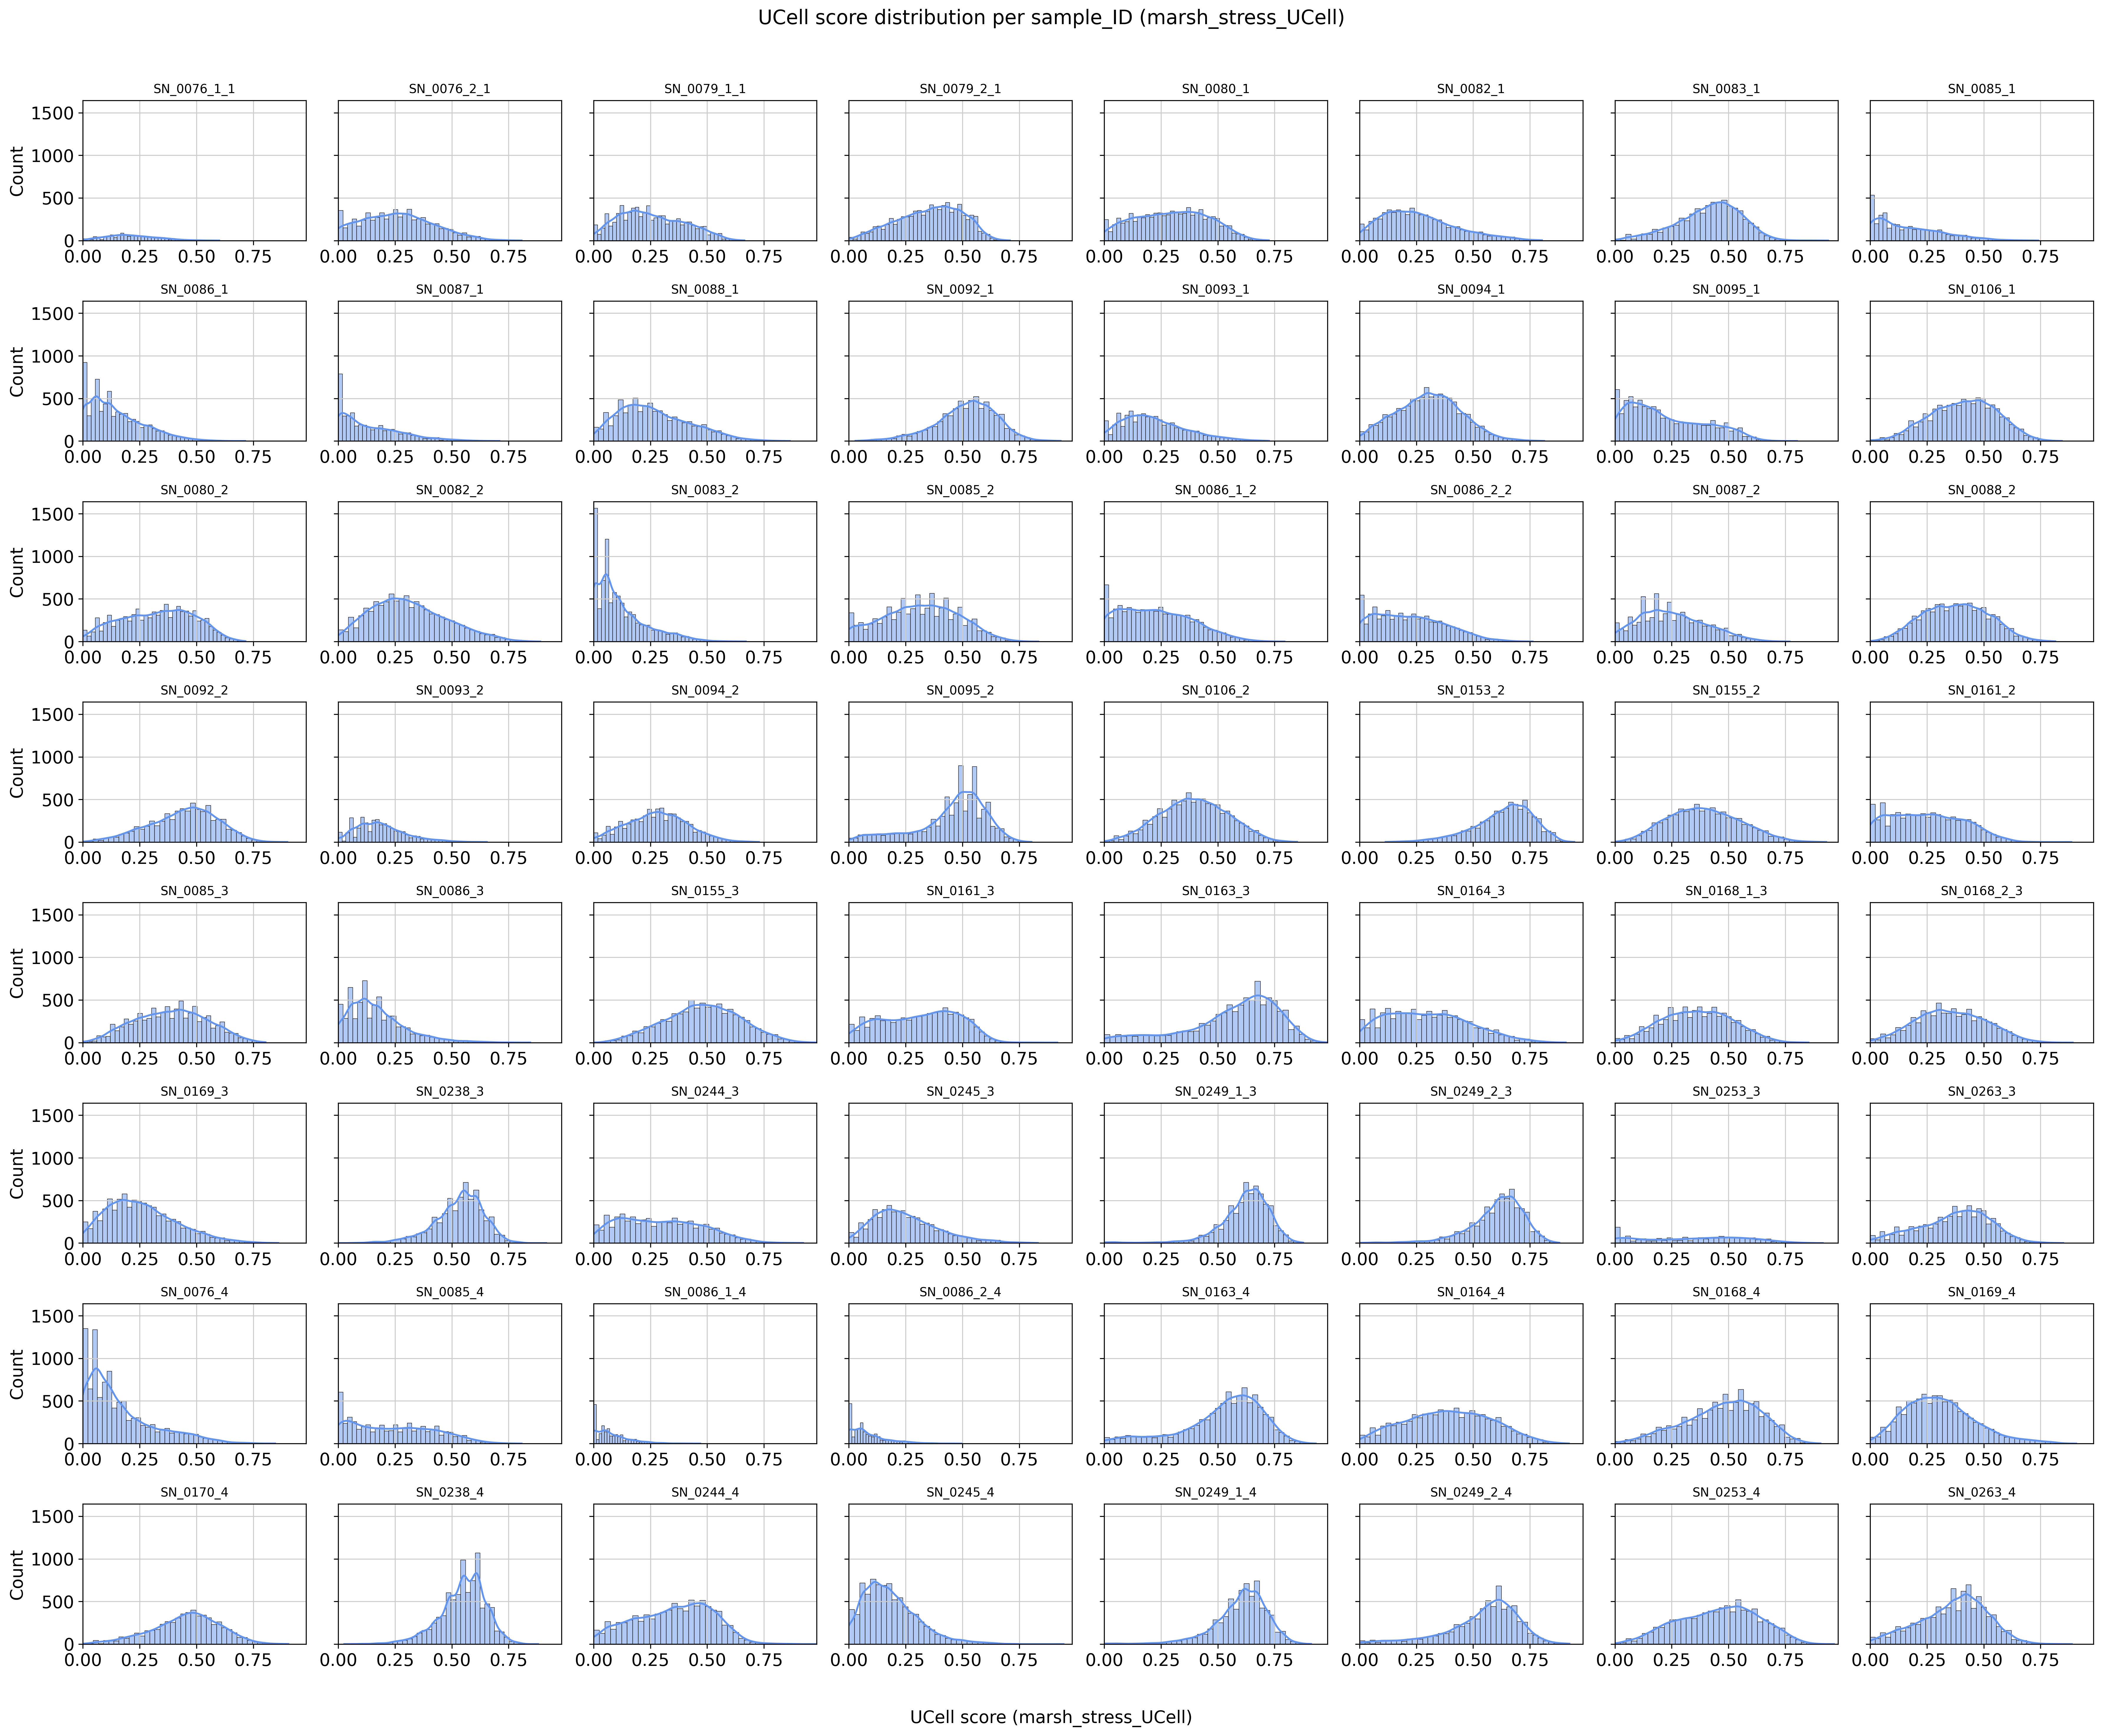

In [ ]:
# Plot UCell score distribution per unique_sample_ID (i.e. each ovary wedge probed)
score_col = "marsh_stress_UCell" if "marsh_stress_UCell" in merged_adata.obs.columns else list(merged_adata.obs.filter(like="_UCell").columns)[0]
samples = merged_adata.obs["unique_sample_ID"].unique()
n_samples = len(samples)
n_cols = 8
n_rows = math.ceil(n_samples / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*2.5), sharey=True)
axes = axes.flatten()

for i, sample in enumerate(samples):
    ax = axes[i]
    sns.histplot(
        merged_adata.obs.loc[merged_adata.obs["unique_sample_ID"] == sample, score_col],
        bins=40, kde=True, ax=ax, color="cornflowerblue"
    )
    ax.set_title(str(sample), fontsize=10)
    ax.set_xlabel("")
    if i % n_cols == 0:
        ax.set_ylabel("Count")
    else:
        ax.set_ylabel("")
    ax.set_xlim(merged_adata.obs[score_col].min(), merged_adata.obs[score_col].max())

# Hide any unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f"UCell score distribution per sample_ID ({score_col})", fontsize=16)
fig.text(0.5, 0.01, f"UCell score ({score_col})", ha="center")
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show();

#### Merged object QC

In [102]:
merged_adata
print(merged_adata.obs.groupby('Age').size())
doublet_percentage = (merged_adata.obs['scDblFinder_class'] == 'doublet').sum() / merged_adata.n_obs * 100
print(f"Percentage of doublets: {doublet_percentage:.2f}%")

AnnData object with n_obs × n_vars = 460100 × 18099
    obs: 'background_fraction', 'cell_probability', 'sample_ID', 'SenNet_ID', 'plex', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'scDblFinder_score', 'scDblFinder_class', 'Age', 'BMI', 'NonOvarian_Cancer_State', 'Smoking_Status_Former', 'Para', 'Para_Gravida_Ratio', 'Simplified_Race_Ethnicity', 'Ovarian_Specific_Benign_Finding', 'Pelvic_Organ_Prolapse', 'Premalignant_Cervical', 'Urinary_Incontinence', 'Procedure_Day', 'Days_Since_Earliest', 'Is_Cancer_Staging_Procedure', 'Uterine_Pathology', 'Surgical_Approach', 'unique_sample_ID', 'marsh_stress_UCell'
    var: 'gene_ids', 'feature_types', 'genome', 'mito'
    layers: 'raw_counts'

Age
50    17311
54    72729
56    17824
57    18116
58    14956
60    16248
61    10286
62     5590
63    79523
65    24327
67    14789
68    11339
69    16581
70    26944
71    18193
74    14663
75    74478
84     6203
dtype: int64
Percentage of doublets: 12.03%


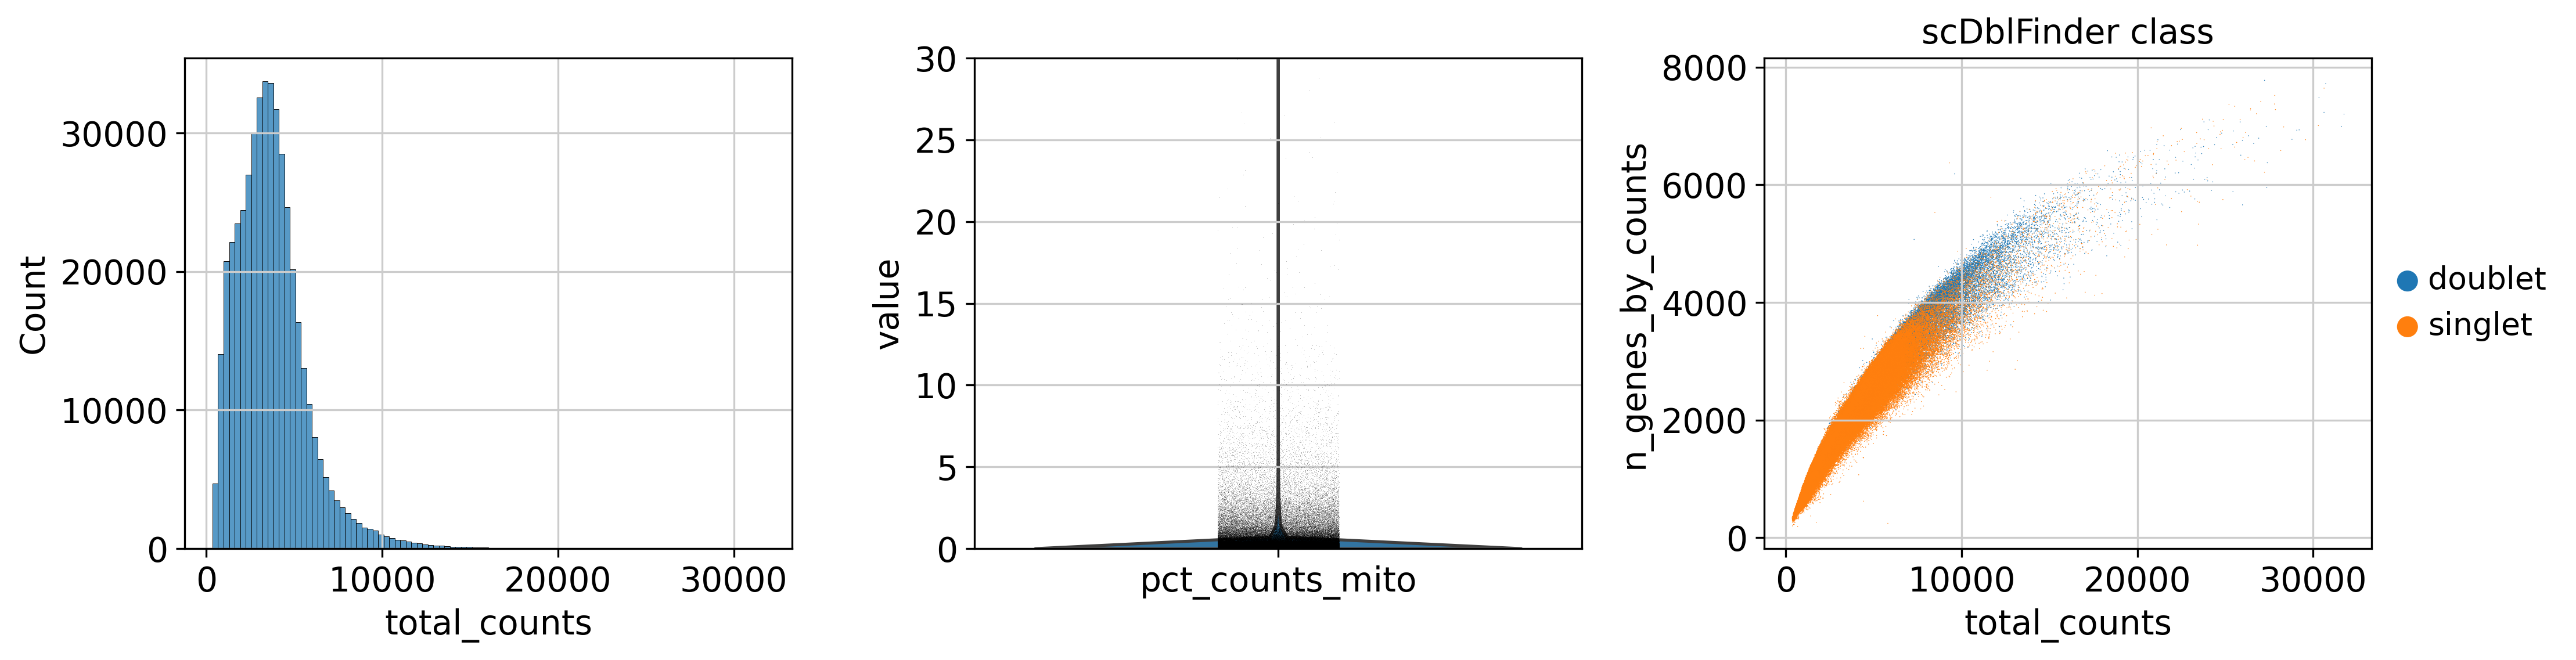

In [103]:
### Plot and assess QC metrics ###

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

hist_plt = sns.histplot(merged_adata.obs['total_counts'], bins=100, kde=False, ax=axs[0])
vln_plt = sc.pl.violin(merged_adata, 'pct_counts_mito', ax=axs[1], size=0.1, show=False)
vln_plt.set_ylim(0,30)
scat_plt = sc.pl.scatter(merged_adata, 'total_counts', 'n_genes_by_counts', ax=axs[2], size = 0.5, color='scDblFinder_class', show=False)

plt.tight_layout()
plt.show();

In [104]:
# Calculate total nuclei above 5% and 10% mito reads
print(f"Percentage of nuclei with >5% mitochondrial counts: {(((merged_adata.obs['pct_counts_mito'] > 5).sum() / merged_adata.n_obs) * 100):.2f}%")
print(f"Percentage of nuclei with >10% mitochondrial counts: {(((merged_adata.obs['pct_counts_mito'] > 10).sum() / merged_adata.n_obs) * 100):.2f}%")

Percentage of nuclei with >5% mitochondrial counts: 0.51%
Percentage of nuclei with >10% mitochondrial counts: 0.08%


In [105]:
# Remove nuclei with >10% mitochondrial counts
merged_adata = merged_adata[merged_adata.obs['pct_counts_mito'] <= 10].copy()
print(merged_adata)

AnnData object with n_obs × n_vars = 459732 × 18099
    obs: 'background_fraction', 'cell_probability', 'sample_ID', 'SenNet_ID', 'plex', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'scDblFinder_score', 'scDblFinder_class', 'Age', 'BMI', 'NonOvarian_Cancer_State', 'Smoking_Status_Former', 'Para', 'Para_Gravida_Ratio', 'Simplified_Race_Ethnicity', 'Ovarian_Specific_Benign_Finding', 'Pelvic_Organ_Prolapse', 'Premalignant_Cervical', 'Urinary_Incontinence', 'Procedure_Day', 'Days_Since_Earliest', 'Is_Cancer_Staging_Procedure', 'Uterine_Pathology', 'Surgical_Approach', 'unique_sample_ID', 'marsh_stress_UCell'
    var: 'gene_ids', 'feature_types', 'genome', 'mito'
    uns: 'scDblFinder_class_colors'
    layers: 'raw_counts'


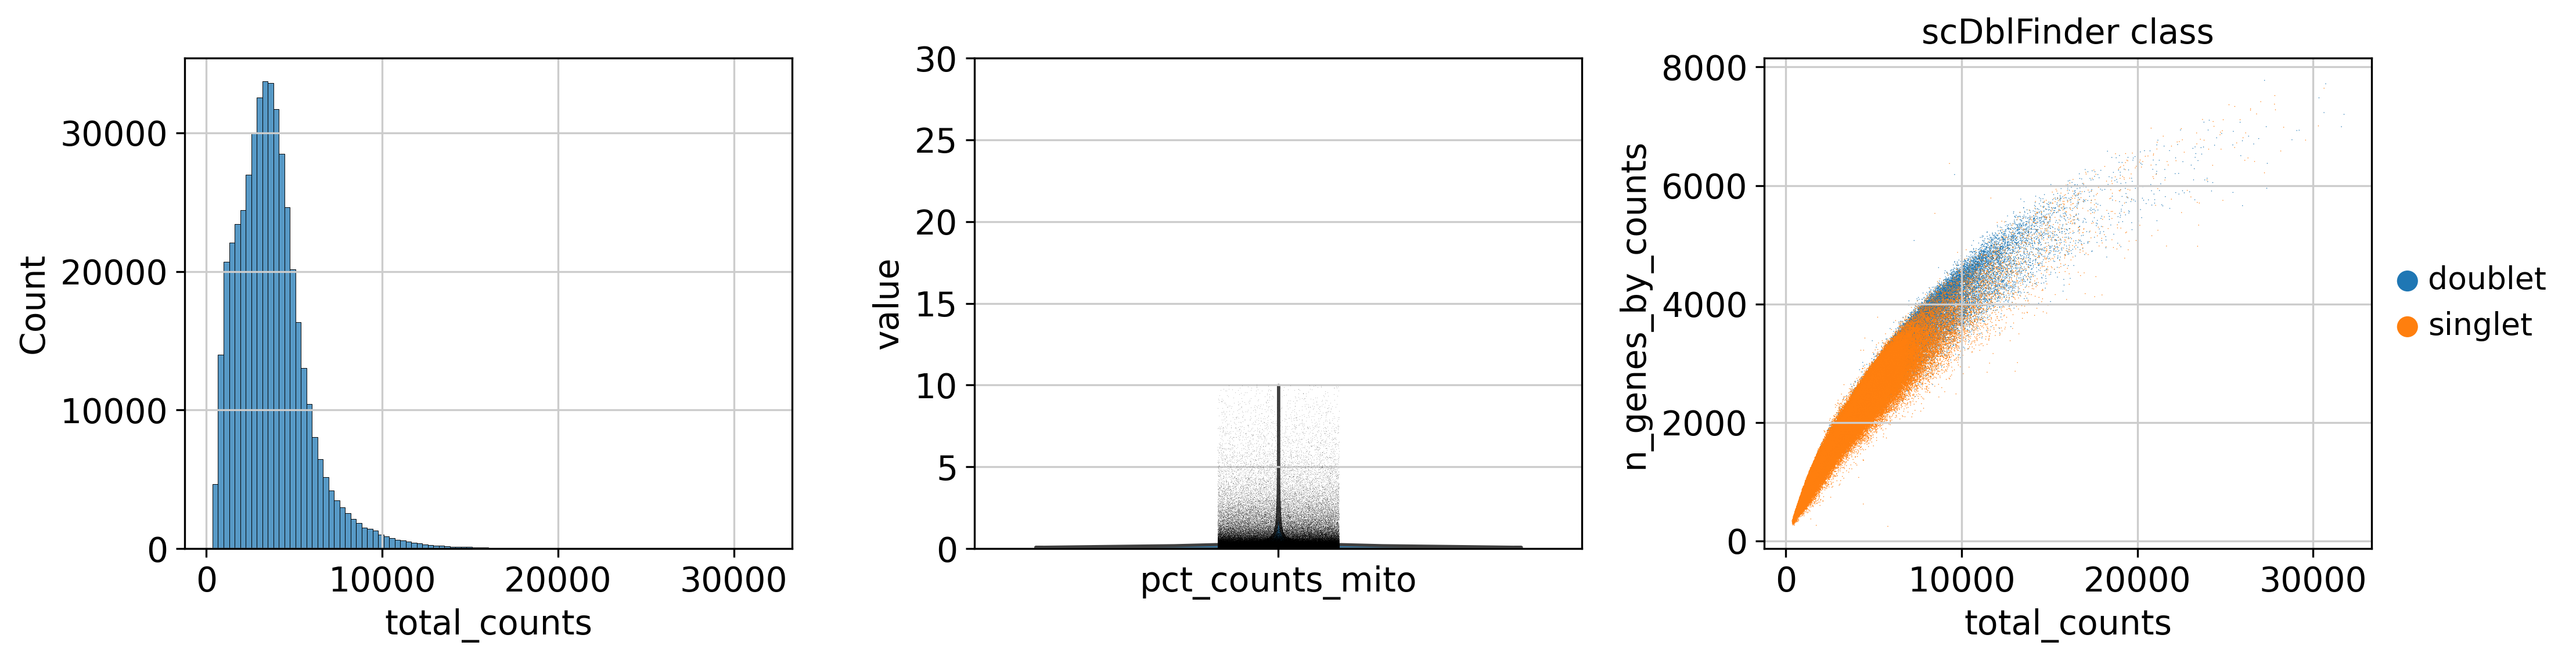

In [106]:
### Plot and assess QC metrics ###

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

hist_plt = sns.histplot(merged_adata.obs['total_counts'], bins=100, kde=False, ax=axs[0])
vln_plt = sc.pl.violin(merged_adata, 'pct_counts_mito', ax=axs[1], size=0.1, show=False)
vln_plt.set_ylim(0,30)
scat_plt = sc.pl.scatter(merged_adata, 'total_counts', 'n_genes_by_counts', ax=axs[2], size = 0.5, color='scDblFinder_class', show=False)

plt.tight_layout()
plt.show();

#### Normalize and save merged object

<Axes: xlabel='log1p_total_counts', ylabel='Count'>

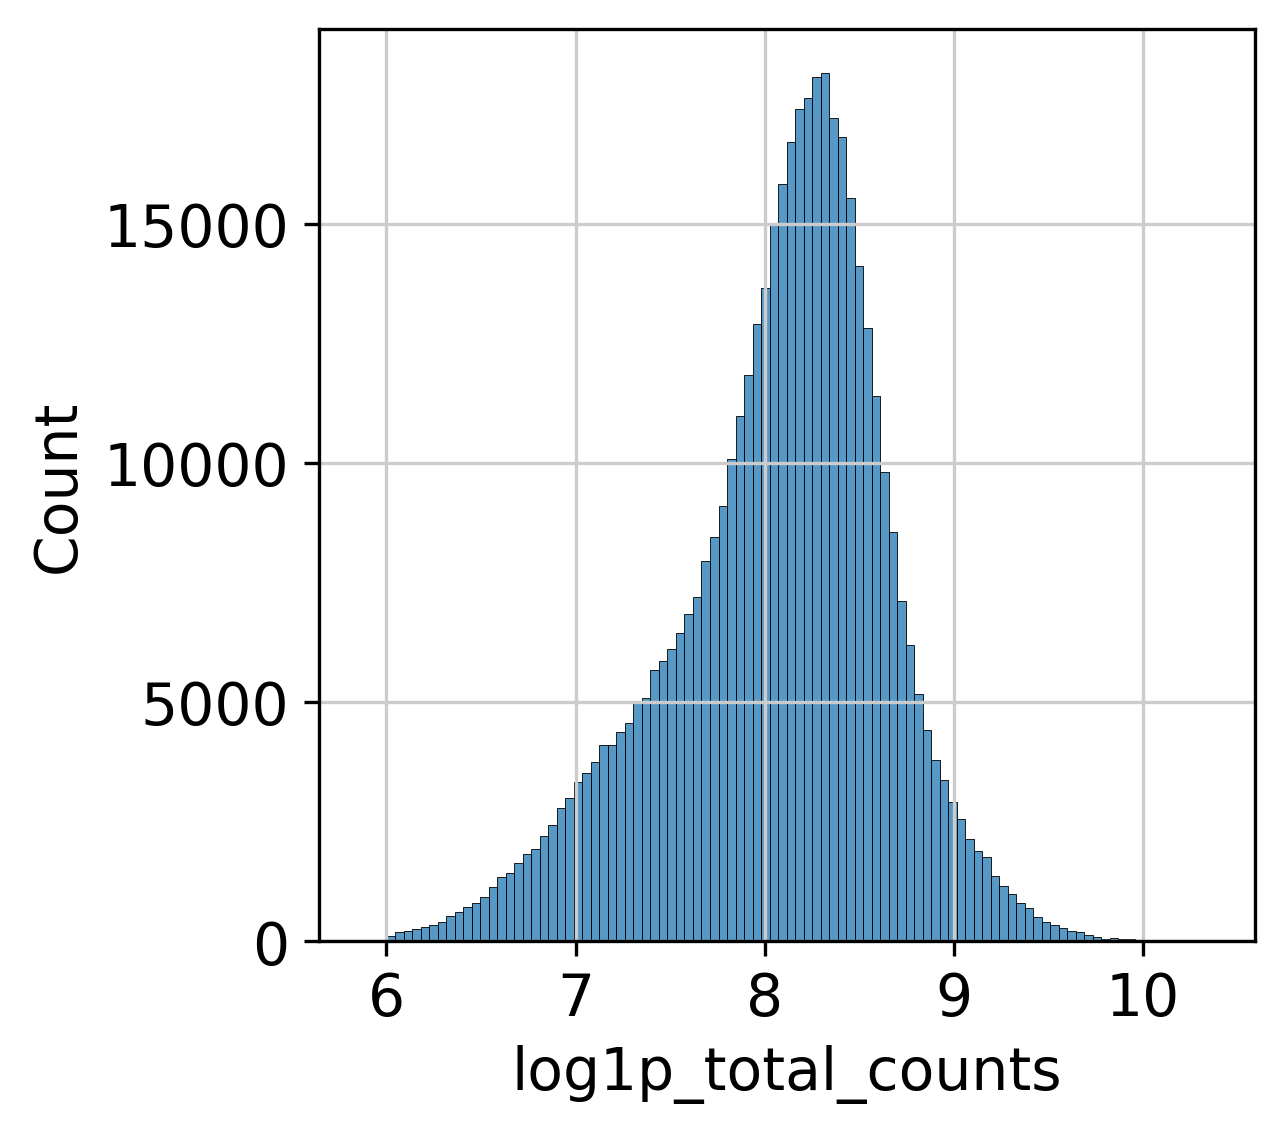

In [107]:
# Normalize and log1p transform, store in independent layer
norm_counts = sc.pp.normalize_total(merged_adata, target_sum=None, inplace=False)
merged_adata.layers['log1p_norm'] = sc.pp.log1p(norm_counts['X'], copy=True)
sns.histplot(merged_adata.obs['log1p_total_counts'], bins=100, kde=False)

In [108]:
merged_adata

AnnData object with n_obs × n_vars = 459732 × 18099
    obs: 'background_fraction', 'cell_probability', 'sample_ID', 'SenNet_ID', 'plex', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'scDblFinder_score', 'scDblFinder_class', 'Age', 'BMI', 'NonOvarian_Cancer_State', 'Smoking_Status_Former', 'Para', 'Para_Gravida_Ratio', 'Simplified_Race_Ethnicity', 'Ovarian_Specific_Benign_Finding', 'Pelvic_Organ_Prolapse', 'Premalignant_Cervical', 'Urinary_Incontinence', 'Procedure_Day', 'Days_Since_Earliest', 'Is_Cancer_Staging_Procedure', 'Uterine_Pathology', 'Surgical_Approach', 'unique_sample_ID', 'marsh_stress_UCell'
    var: 'gene_ids', 'feature_types', 'genome', 'mito'
    uns: 'scDblFinder_class_colors'
    layers: 'raw_counts', 'log1p_norm'

In [ ]:
# Write merged preprocessed AnnData object to file.
merged_adata.write(f"{adata_objdir}/merged_adata.h5ad")

#### Session info

In [110]:
# Print session info
get_session_info()

# R packages
print("\nR Packages:")
r_code = """
library(Seurat)
library(scater)
library(scDblFinder)
library(BiocParallel)

session_info <- sessionInfo()
print(session_info)
"""

# Execute the R code
ro.r(r_code)

scanpy==1.10.2 anndata==0.10.8 umap==0.5.6 numpy==1.26.4 scipy==1.14.1 pandas==2.2.3 scikit-learn==1.5.1 statsmodels==0.14.2 igraph==0.11.6 pynndescent==0.5.13
traitlets version: 5.14.3
jupyter_core version: 5.7.2
datetime version: 5.5
tornado version: 6.4.1
six version: 1.16.0
platformdirs version: 4.2.2
importlib.resources version: 6.4.4
importlib.metadata version: 8.4.0
jupyter_client version: 8.6.2
ipykernel version: 6.29.5
executing version: 2.0.1
asttokens version: 2.4.1
pure_eval version: 0.2.3
stack_data version: 0.6.2
pygments version: 2.18.0
pickleshare version: 0.7.5
decorator version: 5.1.1
wcwidth version: 0.2.13
prompt_toolkit version: 3.0.47
parso version: 0.8.4
jedi version: 0.19.1
IPython version: 8.26.0
comm version: 0.2.2
psutil version: 6.0.0
packaging version: 24.1
debugpy version: 1.8.5
ipywidgets version: 8.1.5
numpy version: 1.26.4
defusedxml version: 0.7.1
cffi version: 1.17.0
pyparsing version: 3.1.4
cycler version: 0.12.1
kiwisolver version: 1.4.5
matplotlib 